# Sweep Results Diagnostics

This notebook analyzes the HDF5 results from the Toy Models of Superposition experiment sweep.

Key diagnostics:
1. **Completion Status**: How many experiments finished vs expected
2. **File Integrity**: Validate all h5 files have expected structure
3. **Fractional Dimensionality Distribution**: Histogram of d/p vs feature count
4. **Loss Convergence**: Track loss trajectories across experiments
5. **Parameter Coverage**: Which (m, sparsity) combinations are complete

In [2]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from itertools import product
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Load Results and Check Completion

In [3]:
# Define the results directory
RESULTS_DIR = Path('results')

# Expected experiment grid (from sweep.py)
N_FEATURES = 1024
M_VALUES = np.logspace(np.log10(16), np.log10(1024), 20).astype(int)
M_VALUES = sorted(set(M_VALUES))  # Remove duplicates from int casting

# Sparsity: 1/(1-S) from 1 to 100
K_VALUES = np.logspace(0, 2, 30)
SPARSITY_VALUES = 1.0 - 1.0 / K_VALUES

SEEDS = [0, 1, 2]

expected_total = len(M_VALUES) * len(SPARSITY_VALUES) * len(SEEDS)
print(f"Expected experiment grid:")
print(f"  n_features: {N_FEATURES}")
print(f"  m_hidden values ({len(M_VALUES)}): {list(M_VALUES)}")
print(f"  Sparsity values ({len(SPARSITY_VALUES)}): {SPARSITY_VALUES[0]:.4f} to {SPARSITY_VALUES[-1]:.4f}")
print(f"  Seeds: {SEEDS}")
print(f"  Total expected: {expected_total}")

Expected experiment grid:
  n_features: 1024
  m_hidden values (20): [16, 19, 24, 30, 38, 47, 59, 74, 92, 114, 142, 177, 221, 275, 342, 426, 531, 660, 822, 1024]
  Sparsity values (30): 0.0000 to 0.9900
  Seeds: [0, 1, 2]
  Total expected: 1800


In [5]:
# Find all h5 files
h5_files = list(RESULTS_DIR.glob('*.h5'))
print(f"Found {len(h5_files)} h5 files")
print(f"Completion: {len(h5_files)}/{expected_total} = {100*len(h5_files)/expected_total:.1f}%")

Found 1800 h5 files
Completion: 1800/1800 = 100.0%


In [6]:
# Parse filenames to extract parameters
def parse_filename(fname):
    """Parse n1024_m16_s0.000000_seed0.h5 -> dict"""
    name = fname.stem
    parts = name.split('_')
    return {
        'n': int(parts[0][1:]),
        'm': int(parts[1][1:]),
        's': float(parts[2][1:]),
        'seed': int(parts[3][4:])
    }

parsed_files = []
for f in h5_files:
    try:
        parsed_files.append({'path': f, **parse_filename(f)})
    except Exception as e:
        print(f"Error parsing {f}: {e}")

print(f"Successfully parsed {len(parsed_files)} files")

Successfully parsed 1800 files


## 2. Analyze Completion Coverage

In [7]:
# Build completion matrix: (m, sparsity) -> set of seeds completed
completion_map = defaultdict(set)
for pf in parsed_files:
    key = (pf['m'], round(pf['s'], 6))
    completion_map[key].add(pf['seed'])

# Expected combinations
expected_keys = set()
for m, s in product(M_VALUES, SPARSITY_VALUES):
    expected_keys.add((int(m), round(s, 6)))

print(f"Unique (m, sparsity) combinations found: {len(completion_map)}")
print(f"Expected unique combinations: {len(expected_keys)}")

Unique (m, sparsity) combinations found: 600
Expected unique combinations: 600


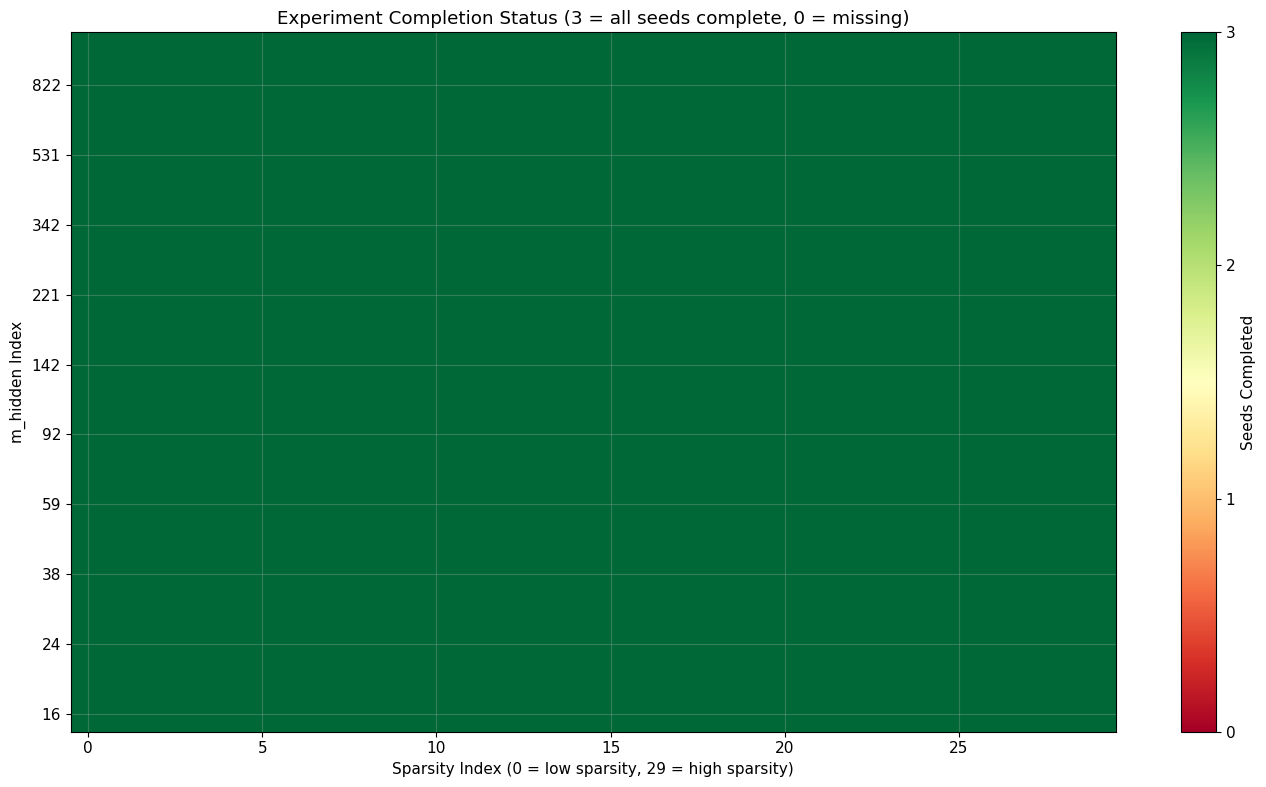


Completion Summary:
  Fully complete (3 seeds): 600 / 600 (100.0%)
  Partially complete: 0
  Missing: 0


In [8]:
# Build completion heatmap
m_unique = sorted(set(M_VALUES))
s_unique = sorted(SPARSITY_VALUES)

completion_matrix = np.zeros((len(m_unique), len(s_unique)))

for i, m in enumerate(m_unique):
    for j, s in enumerate(s_unique):
        key = (int(m), round(s, 6))
        completion_matrix[i, j] = len(completion_map.get(key, set()))

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(completion_matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=3,
               origin='lower')

ax.set_xlabel('Sparsity Index (0 = low sparsity, 29 = high sparsity)')
ax.set_ylabel('m_hidden Index')
ax.set_title('Experiment Completion Status (3 = all seeds complete, 0 = missing)')

# Add m values as y-tick labels
ax.set_yticks(range(0, len(m_unique), 2))
ax.set_yticklabels([m_unique[i] for i in range(0, len(m_unique), 2)])

cbar = plt.colorbar(im, ax=ax, label='Seeds Completed')
cbar.set_ticks([0, 1, 2, 3])

plt.tight_layout()
plt.show()

# Summary stats
fully_complete = (completion_matrix == 3).sum()
partially_complete = ((completion_matrix > 0) & (completion_matrix < 3)).sum()
missing = (completion_matrix == 0).sum()

print(f"\nCompletion Summary:")
print(f"  Fully complete (3 seeds): {fully_complete} / {len(m_unique)*len(s_unique)} ({100*fully_complete/(len(m_unique)*len(s_unique)):.1f}%)")
print(f"  Partially complete: {partially_complete}")
print(f"  Missing: {missing}")

## 3. Validate H5 File Integrity

In [9]:
def validate_h5_file(filepath):
    """Check if an h5 file has all expected datasets and attributes."""
    issues = []
    try:
        with h5py.File(filepath, 'r') as f:
            # Check required attributes
            required_attrs = ['n_features', 'm_hidden', 'sparsity', 'seed', 
                             'total_steps', 'checkpoint_every', 'batch_size', 'lr']
            for attr in required_attrs:
                if attr not in f.attrs:
                    issues.append(f"Missing attribute: {attr}")
            
            # Check required datasets
            required_datasets = ['checkpoint_steps', 'fractional_dims', 'feature_norms', 'losses']
            for ds in required_datasets:
                if ds not in f:
                    issues.append(f"Missing dataset: {ds}")
            
            # Validate shapes if datasets exist
            if 'checkpoint_steps' in f and 'fractional_dims' in f:
                n_checkpoints = f['checkpoint_steps'].shape[0]
                fd_shape = f['fractional_dims'].shape
                if fd_shape[0] != n_checkpoints:
                    issues.append(f"Shape mismatch: checkpoints={n_checkpoints}, fractional_dims={fd_shape}")
            
            # Check for NaN/Inf values
            if 'fractional_dims' in f:
                fd = f['fractional_dims'][:]
                nan_count = np.isnan(fd).sum()
                inf_count = np.isinf(fd).sum()
                if nan_count > 0:
                    issues.append(f"NaN values in fractional_dims: {nan_count}")
                if inf_count > 0:
                    issues.append(f"Inf values in fractional_dims: {inf_count}")
            
            if 'losses' in f:
                losses = f['losses'][:]
                if np.isnan(losses).any():
                    issues.append(f"NaN in losses")
                if np.isinf(losses).any():
                    issues.append(f"Inf in losses")
    except Exception as e:
        issues.append(f"Read error: {str(e)}")
    
    return issues

# Validate all files
print("Validating all h5 files...")
validation_results = {}
corrupted_files = []

for pf in parsed_files:
    issues = validate_h5_file(pf['path'])
    validation_results[pf['path']] = issues
    if issues:
        corrupted_files.append((pf['path'], issues))

print(f"\nValidation Complete:")
print(f"  Valid files: {len(parsed_files) - len(corrupted_files)}")
print(f"  Files with issues: {len(corrupted_files)}")

if corrupted_files:
    print(f"\nFiles with issues (showing first 10):")
    for path, issues in corrupted_files[:10]:
        print(f"  {path.name}: {issues}")

Validating all h5 files...

Validation Complete:
  Valid files: 1800
  Files with issues: 0


## 4. Load All Valid Data

In [10]:
# Load data from all valid files
all_data = []

for pf in parsed_files:
    if pf['path'] in [cf[0] for cf in corrupted_files]:
        continue  # Skip corrupted files
    
    try:
        with h5py.File(pf['path'], 'r') as f:
            data = {
                'path': pf['path'],
                'n': f.attrs['n_features'],
                'm': f.attrs['m_hidden'],
                'sparsity': f.attrs['sparsity'],
                'seed': f.attrs['seed'],
                'total_steps': f.attrs['total_steps'],
                'checkpoint_steps': f['checkpoint_steps'][:],
                'fractional_dims': f['fractional_dims'][:],  # (n_checkpoints, n_features)
                'feature_norms': f['feature_norms'][:],
                'losses': f['losses'][:]
            }
            all_data.append(data)
    except Exception as e:
        print(f"Error loading {pf['path']}: {e}")

print(f"Successfully loaded {len(all_data)} experiments")

Successfully loaded 1800 experiments


## 5. Fractional Dimensionality Distribution

Plot histogram: x = d/p (fractional dimensionality / p where p = m/n), y = count of features

In [11]:
# Compute d/p for all features across all final checkpoints
# d_i = fractional dimensionality of feature i
# p = m/n = compression ratio

def compute_d_over_p(data):
    """Compute d/p for final checkpoint."""
    n = data['n']
    m = data['m']
    p = m / n  # compression ratio
    
    # Get final checkpoint fractional dims (last row)
    final_fd = data['fractional_dims'][-1]  # (n_features,)
    
    # d/p for each feature
    d_over_p = final_fd / p
    
    return d_over_p, p, data['sparsity']

# Collect all d/p values
all_d_over_p = []
metadata = []  # Store (m, sparsity, seed) for each experiment

for data in all_data:
    d_over_p, p, s = compute_d_over_p(data)
    all_d_over_p.append(d_over_p)
    metadata.append({'m': data['m'], 'p': p, 'sparsity': s, 'seed': data['seed']})

print(f"Collected fractional dimensionality from {len(all_d_over_p)} experiments")
print(f"Total feature measurements: {sum(len(d) for d in all_d_over_p)}")

Collected fractional dimensionality from 1800 experiments
Total feature measurements: 1843200


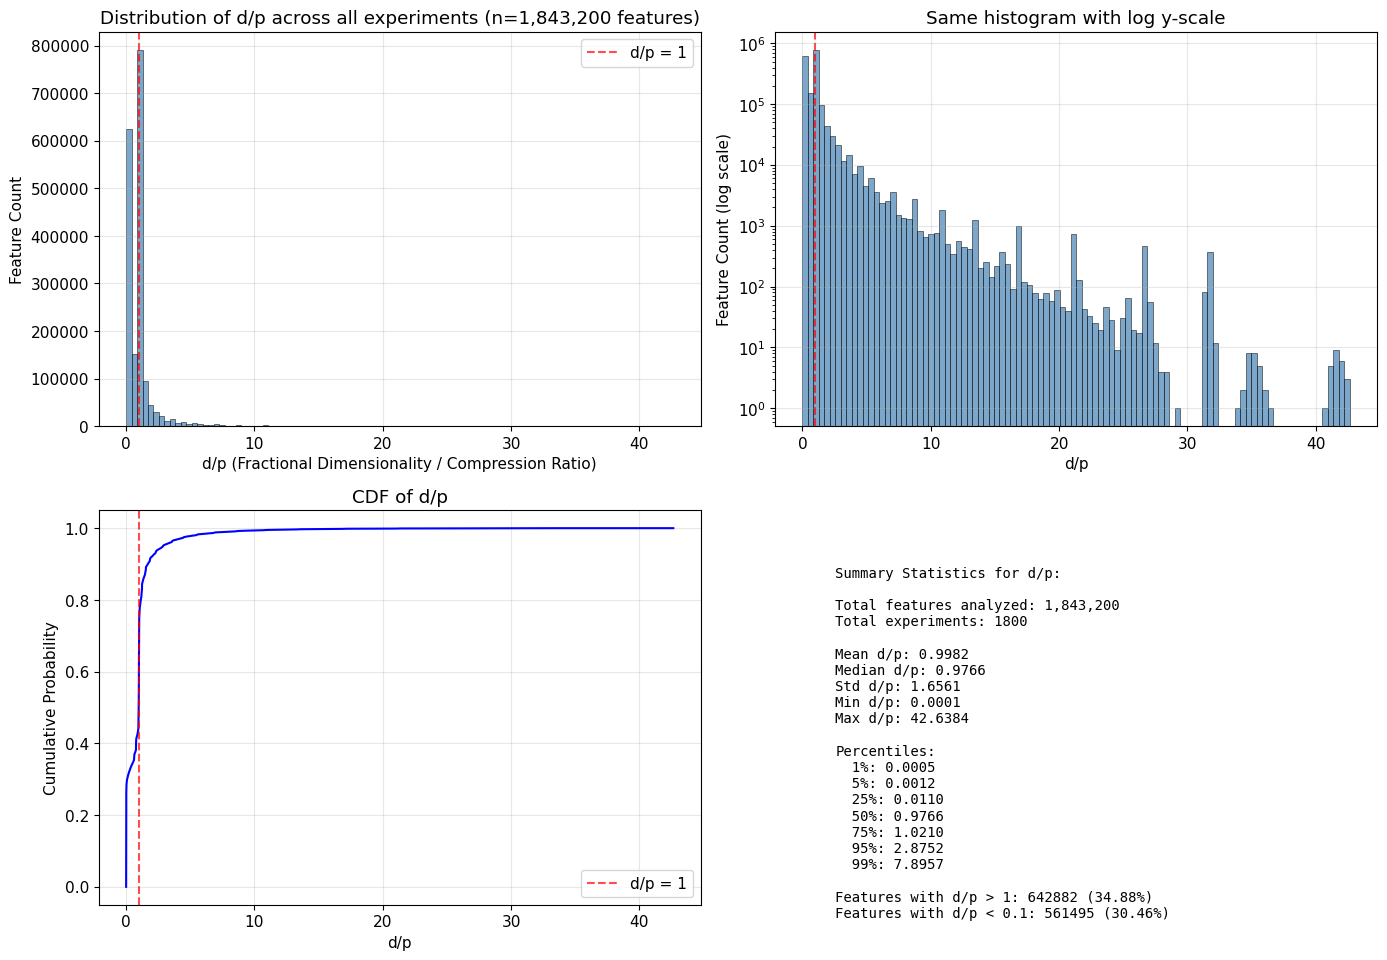

In [15]:
# Global histogram of d/p values
all_d_flat = np.concatenate(all_d_over_p)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Overall histogram
ax = axes[0, 0]
ax.hist(all_d_flat, bins=100, density=False, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_xlabel('d/p (Fractional Dimensionality / Compression Ratio)')
ax.set_ylabel('Feature Count')
ax.set_title(f'Distribution of d/p across all experiments (n={len(all_d_flat):,} features)')
ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='d/p = 1')
ax.legend()

# 2. Log-scale histogram
ax = axes[0, 1]
ax.hist(all_d_flat, bins=100, density=False, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_xlabel('d/p')
ax.set_ylabel('Feature Count (log scale)')
ax.set_title('Same histogram with log y-scale')
ax.set_yscale('log')
ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.7)

# 3. CDF
ax = axes[1, 0]
sorted_d = np.sort(all_d_flat)
cdf = np.arange(1, len(sorted_d) + 1) / len(sorted_d)
ax.plot(sorted_d, cdf, 'b-', linewidth=1.5)
ax.set_xlabel('d/p')
ax.set_ylabel('Cumulative Probability')
ax.set_title('CDF of d/p')
ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='d/p = 1')
ax.legend()

# 4. Statistics
ax = axes[1, 1]
ax.axis('off')
stats_text = f"""
Summary Statistics for d/p:

Total features analyzed: {len(all_d_flat):,}
Total experiments: {len(all_data)}

Mean d/p: {np.mean(all_d_flat):.4f}
Median d/p: {np.median(all_d_flat):.4f}
Std d/p: {np.std(all_d_flat):.4f}
Min d/p: {np.min(all_d_flat):.4f}
Max d/p: {np.max(all_d_flat):.4f}

Percentiles:
  1%: {np.percentile(all_d_flat, 1):.4f}
  5%: {np.percentile(all_d_flat, 5):.4f}
  25%: {np.percentile(all_d_flat, 25):.4f}
  50%: {np.percentile(all_d_flat, 50):.4f}
  75%: {np.percentile(all_d_flat, 75):.4f}
  95%: {np.percentile(all_d_flat, 95):.4f}
  99%: {np.percentile(all_d_flat, 99):.4f}

Features with d/p > 1: {(all_d_flat > 1).sum()} ({100*(all_d_flat > 1).sum()/len(all_d_flat):.2f}%)
Features with d/p < 0.1: {(all_d_flat < 0.1).sum()} ({100*(all_d_flat < 0.1).sum()/len(all_d_flat):.2f}%)
"""
ax.text(0.1, 0.9, stats_text, transform=ax.transAxes, fontsize=10, 
        verticalalignment='top', fontfamily='monospace')

plt.tight_layout()
plt.show()

## 6. Fractional Dimensionality by Sparsity

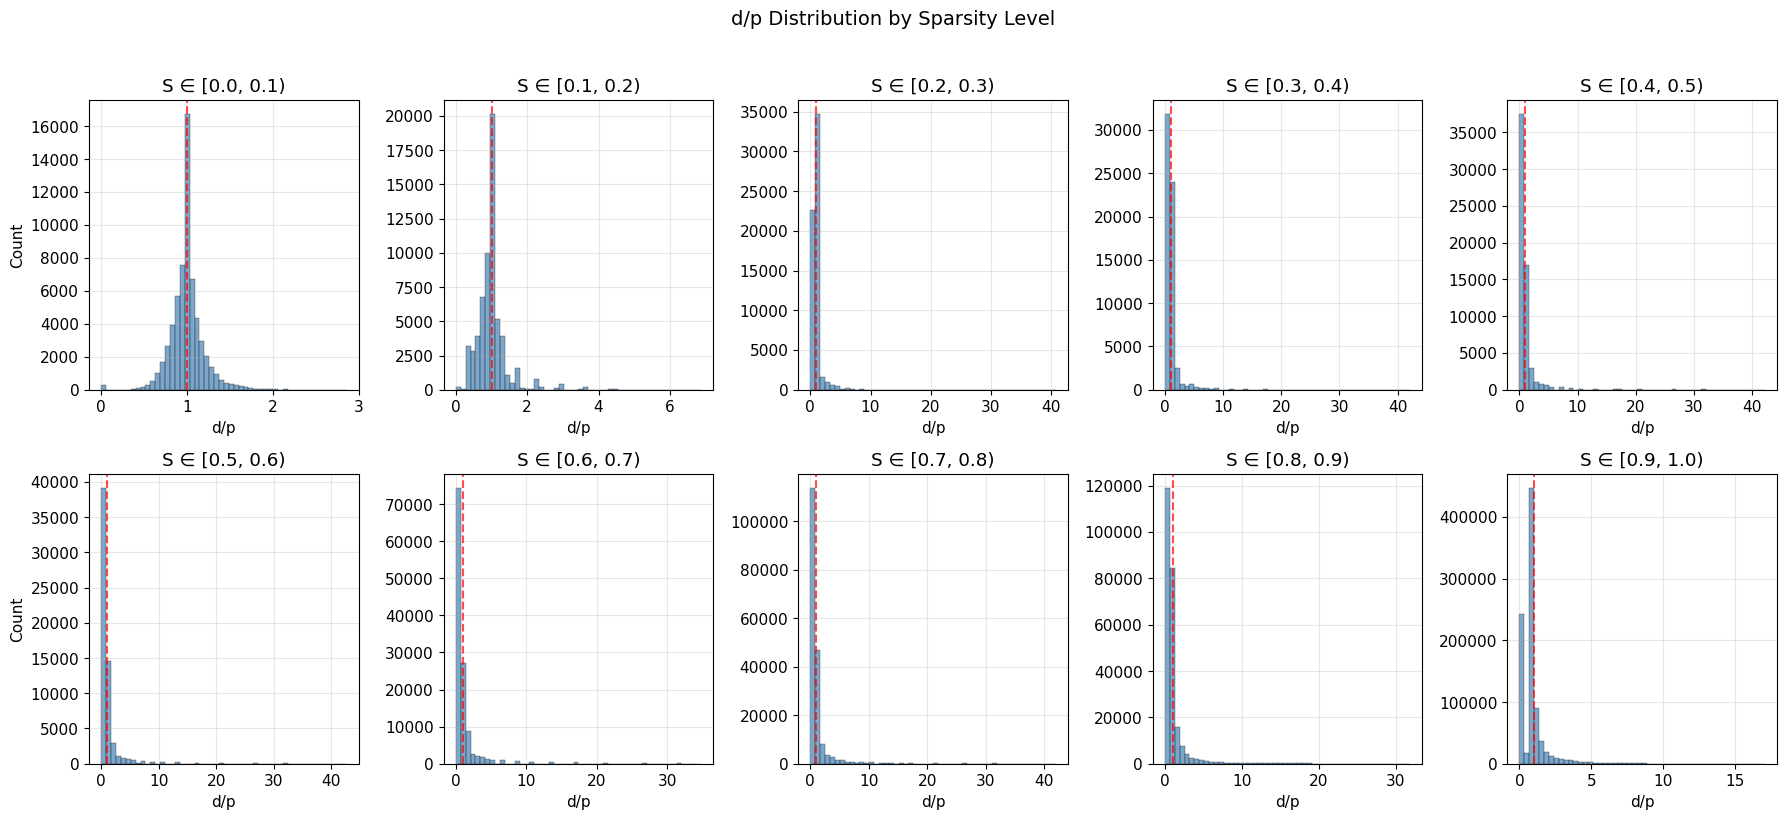

In [12]:
# Group d/p by sparsity level
sparsity_bins = np.linspace(0, 1, 11)  # 0-0.1, 0.1-0.2, ..., 0.9-1.0
sparsity_groups = {i: [] for i in range(10)}

for d_over_p, meta in zip(all_d_over_p, metadata):
    s = meta['sparsity']
    bin_idx = min(int(s * 10), 9)
    sparsity_groups[bin_idx].extend(d_over_p)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    data = sparsity_groups[i]
    if len(data) > 0:
        ax.hist(data, bins=50, density=False, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.3)
        ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.7)
    ax.set_title(f'S ∈ [{sparsity_bins[i]:.1f}, {sparsity_bins[i+1]:.1f})')
    ax.set_xlabel('d/p')
    if i % 5 == 0:
        ax.set_ylabel('Count')

plt.suptitle('d/p Distribution by Sparsity Level', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Fractional Dimensionality by m_hidden (Compression Ratio)

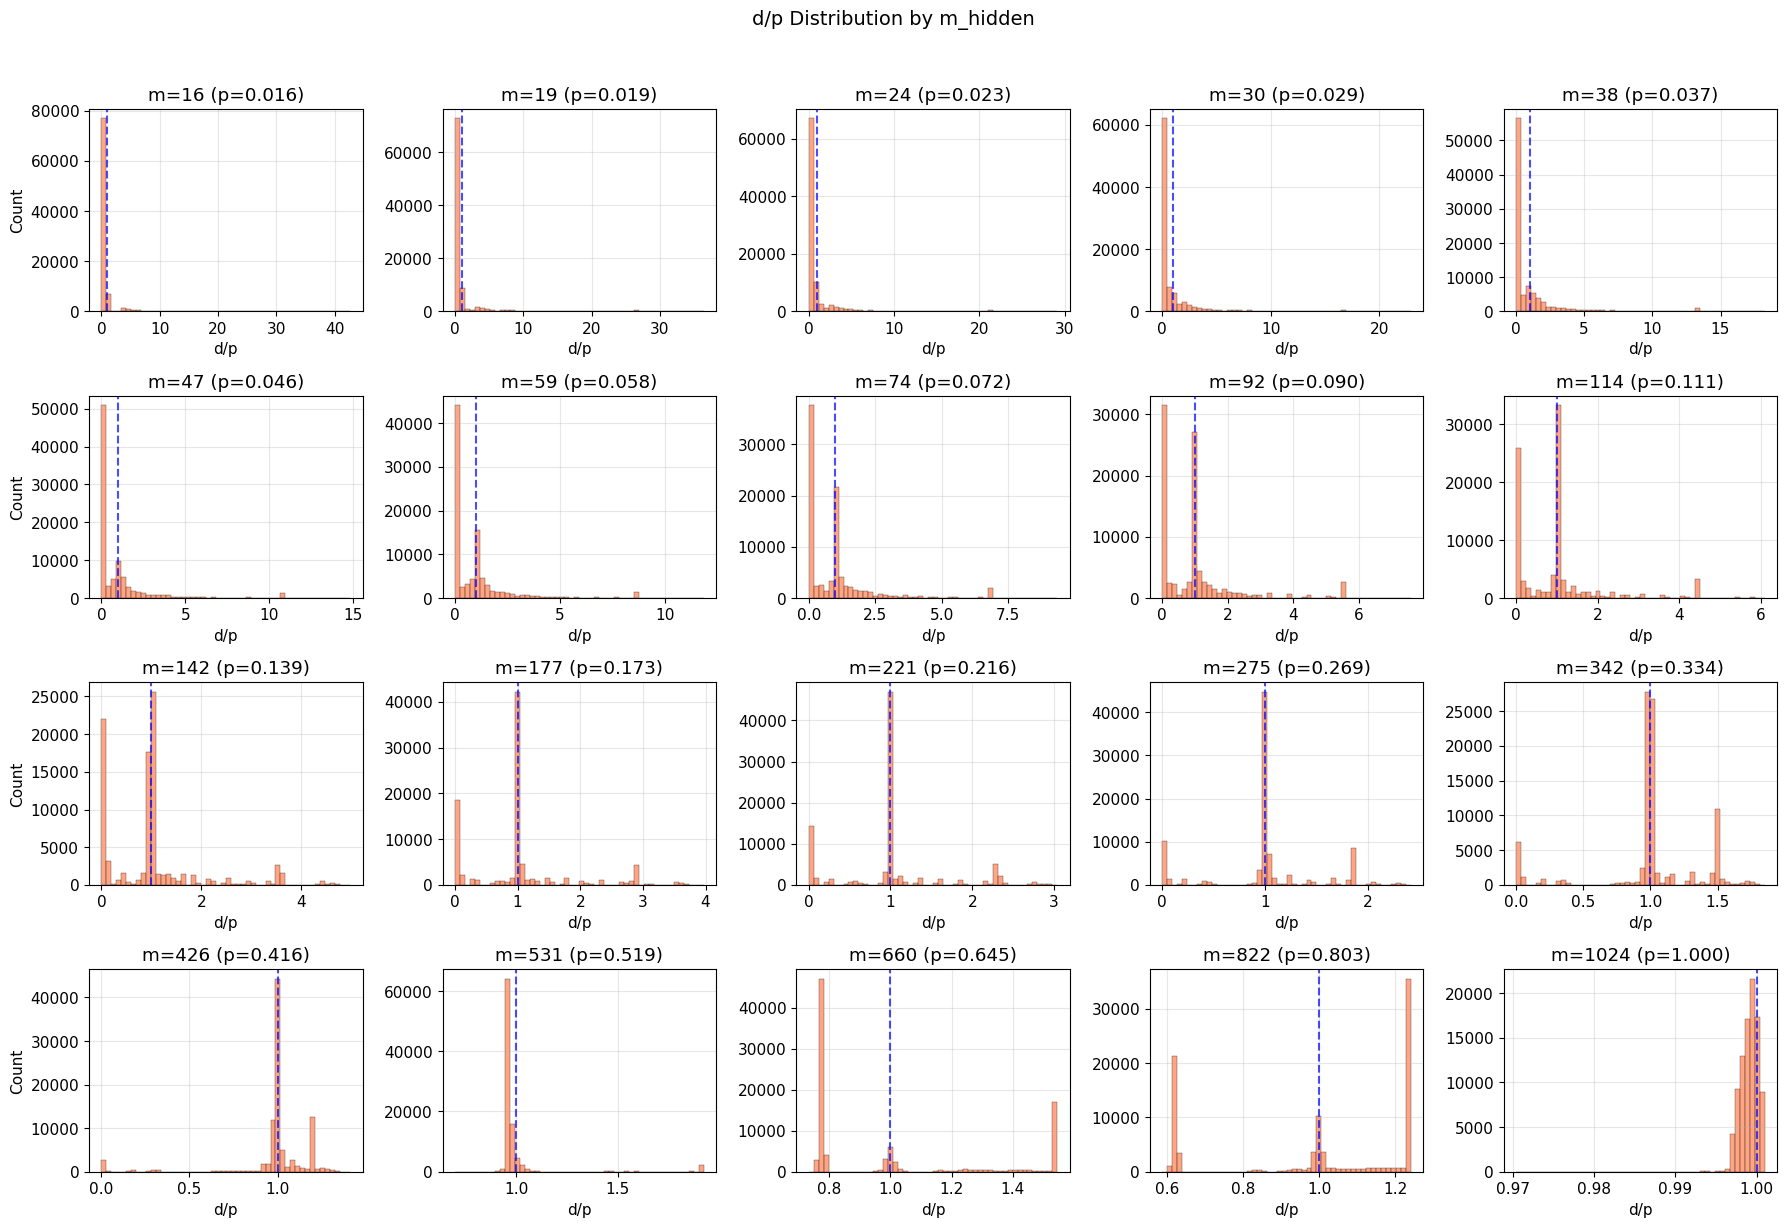

In [13]:
# Group by m value
m_groups = defaultdict(list)

for d_over_p, meta in zip(all_d_over_p, metadata):
    m_groups[meta['m']].extend(d_over_p)

# Plot for available m values
available_m = sorted(m_groups.keys())
n_plots = len(available_m)
n_cols = 5
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_plots == 1 else axes

for idx, m in enumerate(available_m):
    ax = axes[idx]
    data = m_groups[m]
    if len(data) > 0:
        ax.hist(data, bins=50, density=False, alpha=0.7, color='coral', edgecolor='black', linewidth=0.3)
        ax.axvline(x=1.0, color='blue', linestyle='--', alpha=0.7)
    p = m / N_FEATURES
    ax.set_title(f'm={m} (p={p:.3f})')
    ax.set_xlabel('d/p')
    if idx % n_cols == 0:
        ax.set_ylabel('Count')

# Hide unused subplots
for idx in range(len(available_m), len(axes)):
    axes[idx].axis('off')

plt.suptitle('d/p Distribution by m_hidden', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Mean d/p Heatmap (m vs Sparsity)

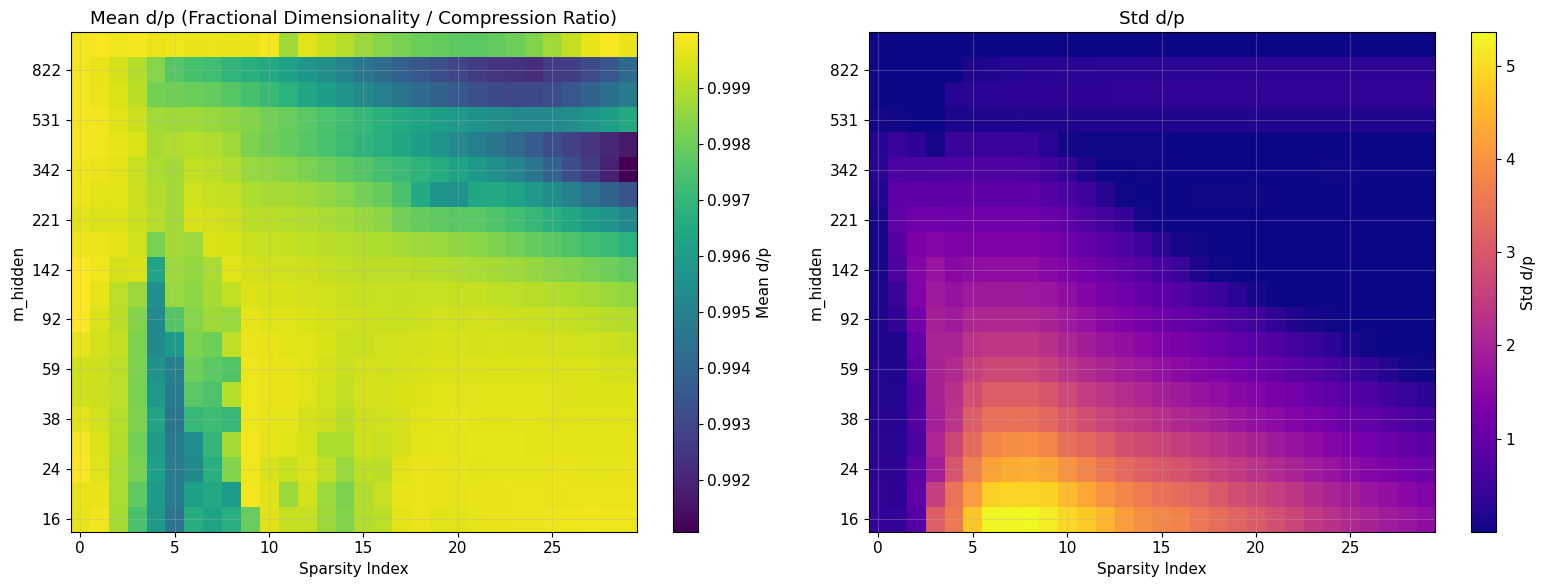

In [14]:
# Build heatmap of mean d/p
mean_d_over_p_matrix = np.full((len(m_unique), len(s_unique)), np.nan)
std_d_over_p_matrix = np.full((len(m_unique), len(s_unique)), np.nan)

# Group experiments by (m, sparsity)
ms_groups = defaultdict(list)
for d_over_p, meta in zip(all_d_over_p, metadata):
    ms_groups[(meta['m'], round(meta['sparsity'], 6))].append(d_over_p)

for i, m in enumerate(m_unique):
    for j, s in enumerate(s_unique):
        key = (int(m), round(s, 6))
        if key in ms_groups:
            combined = np.concatenate(ms_groups[key])
            mean_d_over_p_matrix[i, j] = np.mean(combined)
            std_d_over_p_matrix[i, j] = np.std(combined)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mean heatmap
ax = axes[0]
im = ax.imshow(mean_d_over_p_matrix, aspect='auto', cmap='viridis', origin='lower')
ax.set_xlabel('Sparsity Index')
ax.set_ylabel('m_hidden')
ax.set_title('Mean d/p (Fractional Dimensionality / Compression Ratio)')
ax.set_yticks(range(0, len(m_unique), 2))
ax.set_yticklabels([m_unique[i] for i in range(0, len(m_unique), 2)])
plt.colorbar(im, ax=ax, label='Mean d/p')

# Std heatmap
ax = axes[1]
im = ax.imshow(std_d_over_p_matrix, aspect='auto', cmap='plasma', origin='lower')
ax.set_xlabel('Sparsity Index')
ax.set_ylabel('m_hidden')
ax.set_title('Std d/p')
ax.set_yticks(range(0, len(m_unique), 2))
ax.set_yticklabels([m_unique[i] for i in range(0, len(m_unique), 2)])
plt.colorbar(im, ax=ax, label='Std d/p')

plt.tight_layout()
plt.show()

## 9. Loss Convergence Analysis

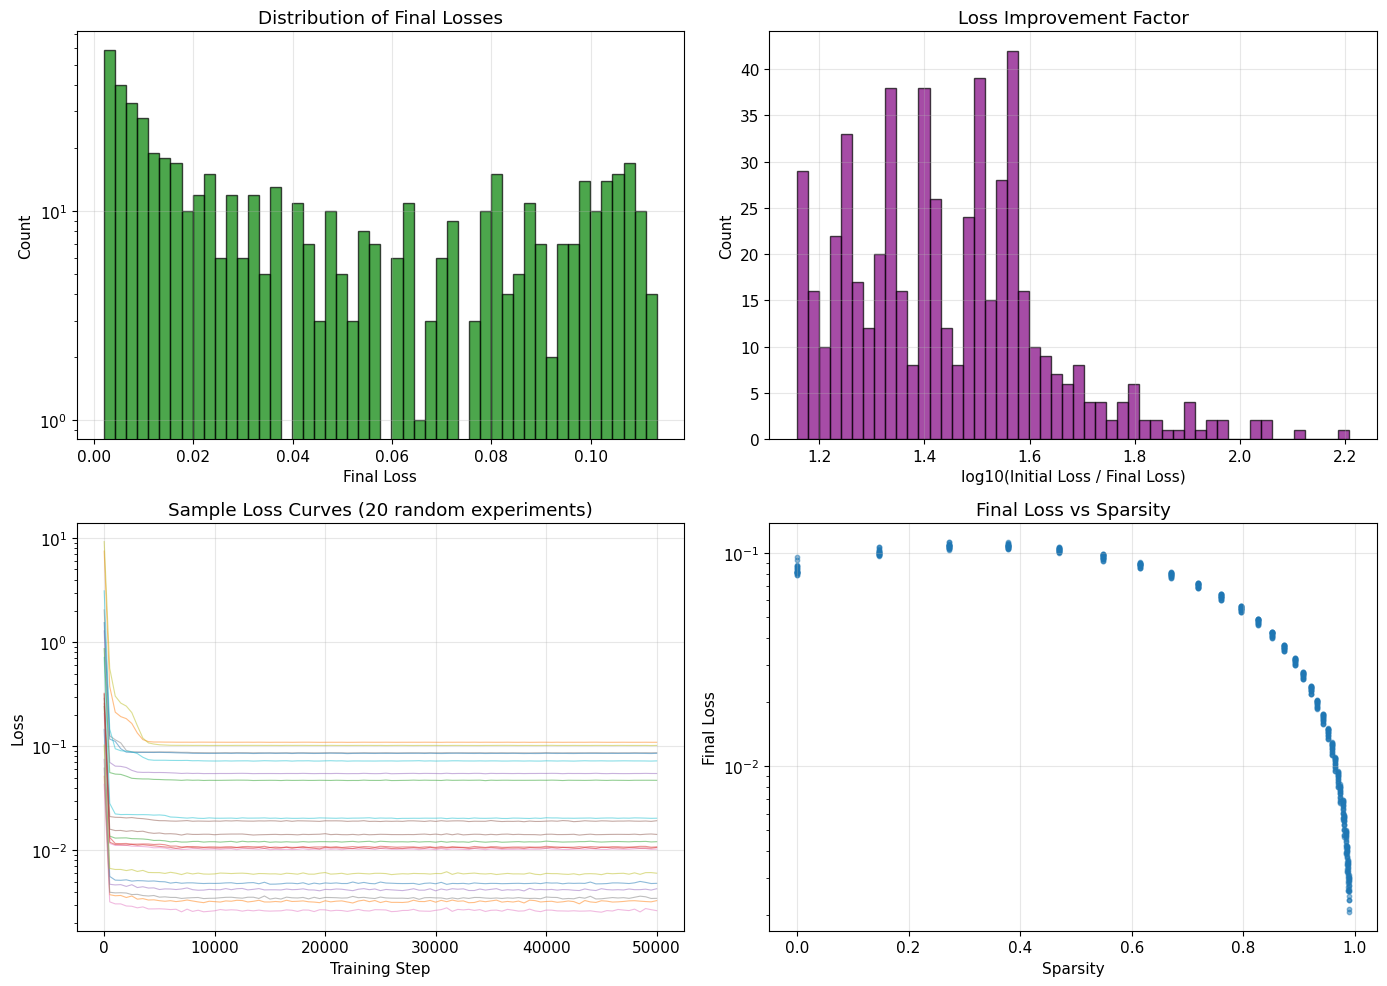


Loss Statistics:
  Mean final loss: 0.043803
  Median final loss: 0.030807
  Max final loss: 0.113247
  95th percentile: 0.106819
  Experiments with high loss (>95th %ile): 28


In [13]:
# Analyze final losses
final_losses = [data['losses'][-1] for data in all_data]
initial_losses = [data['losses'][0] for data in all_data]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Final loss distribution
ax = axes[0, 0]
ax.hist(final_losses, bins=50, alpha=0.7, color='green', edgecolor='black')
ax.set_xlabel('Final Loss')
ax.set_ylabel('Count')
ax.set_title('Distribution of Final Losses')
ax.set_yscale('log')

# Loss improvement ratio
ax = axes[0, 1]
improvement = np.array(initial_losses) / (np.array(final_losses) + 1e-10)
ax.hist(np.log10(improvement + 1), bins=50, alpha=0.7, color='purple', edgecolor='black')
ax.set_xlabel('log10(Initial Loss / Final Loss)')
ax.set_ylabel('Count')
ax.set_title('Loss Improvement Factor')

# Sample loss curves
ax = axes[1, 0]
sample_indices = np.random.choice(len(all_data), min(20, len(all_data)), replace=False)
for idx in sample_indices:
    data = all_data[idx]
    ax.plot(data['checkpoint_steps'], data['losses'], alpha=0.5, linewidth=0.8)
ax.set_xlabel('Training Step')
ax.set_ylabel('Loss')
ax.set_title('Sample Loss Curves (20 random experiments)')
ax.set_yscale('log')

# Final loss vs sparsity
ax = axes[1, 1]
sparsities = [meta['sparsity'] for meta in metadata]
ax.scatter(sparsities, final_losses, alpha=0.5, s=10)
ax.set_xlabel('Sparsity')
ax.set_ylabel('Final Loss')
ax.set_title('Final Loss vs Sparsity')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

# Check for potential issues
high_loss_threshold = np.percentile(final_losses, 95)
high_loss_experiments = [(data, meta) for data, meta in zip(all_data, metadata) 
                         if data['losses'][-1] > high_loss_threshold]

print(f"\nLoss Statistics:")
print(f"  Mean final loss: {np.mean(final_losses):.6f}")
print(f"  Median final loss: {np.median(final_losses):.6f}")
print(f"  Max final loss: {np.max(final_losses):.6f}")
print(f"  95th percentile: {high_loss_threshold:.6f}")
print(f"  Experiments with high loss (>95th %ile): {len(high_loss_experiments)}")

## 10. Feature Norm Analysis

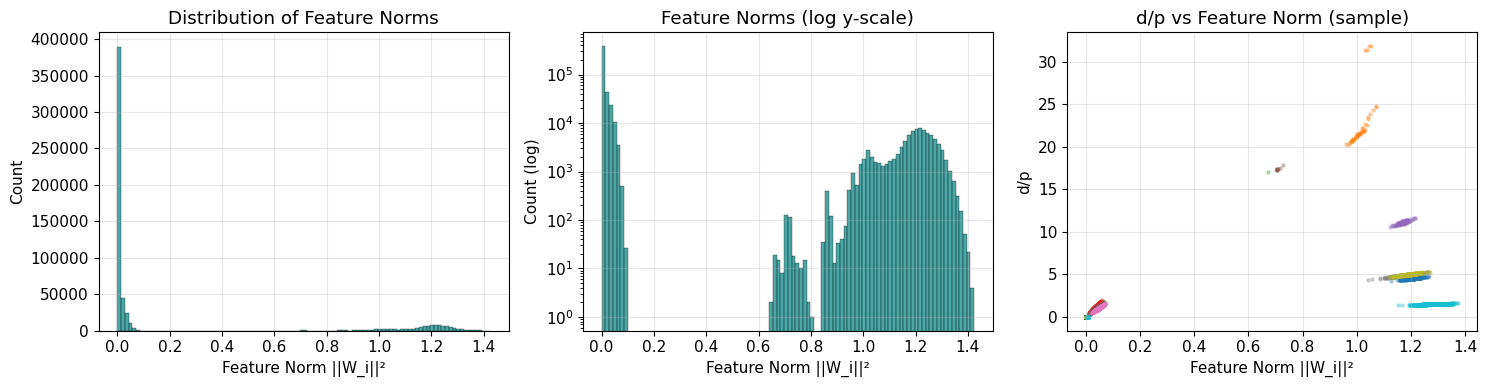


Feature Norm Statistics:
  Mean norm: 0.197248
  Median norm: 0.001382
  Dead features (norm < 1e-06): 0 (0.00%)


In [14]:
# Analyze feature norms at final checkpoint
all_final_norms = []
for data in all_data:
    final_norms = data['feature_norms'][-1]  # (n_features,)
    all_final_norms.extend(final_norms)

all_final_norms = np.array(all_final_norms)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Norm distribution
ax = axes[0]
ax.hist(all_final_norms, bins=100, alpha=0.7, color='teal', edgecolor='black', linewidth=0.3)
ax.set_xlabel('Feature Norm ||W_i||²')
ax.set_ylabel('Count')
ax.set_title('Distribution of Feature Norms')

# Log histogram
ax = axes[1]
ax.hist(all_final_norms, bins=100, alpha=0.7, color='teal', edgecolor='black', linewidth=0.3)
ax.set_xlabel('Feature Norm ||W_i||²')
ax.set_ylabel('Count (log)')
ax.set_title('Feature Norms (log y-scale)')
ax.set_yscale('log')

# Norm vs d/p scatter
ax = axes[2]
sample_idx = np.random.choice(len(all_data), min(10, len(all_data)), replace=False)
for idx in sample_idx:
    norms = all_data[idx]['feature_norms'][-1]
    d_p = all_d_over_p[idx]
    ax.scatter(norms, d_p, alpha=0.3, s=5)
ax.set_xlabel('Feature Norm ||W_i||²')
ax.set_ylabel('d/p')
ax.set_title('d/p vs Feature Norm (sample)')

plt.tight_layout()
plt.show()

# Zero or near-zero norms (dead features)
dead_threshold = 1e-6
dead_features = (all_final_norms < dead_threshold).sum()
print(f"\nFeature Norm Statistics:")
print(f"  Mean norm: {np.mean(all_final_norms):.6f}")
print(f"  Median norm: {np.median(all_final_norms):.6f}")
print(f"  Dead features (norm < {dead_threshold}): {dead_features} ({100*dead_features/len(all_final_norms):.2f}%)")

## 11. Fractional Dimensionality Evolution Over Training

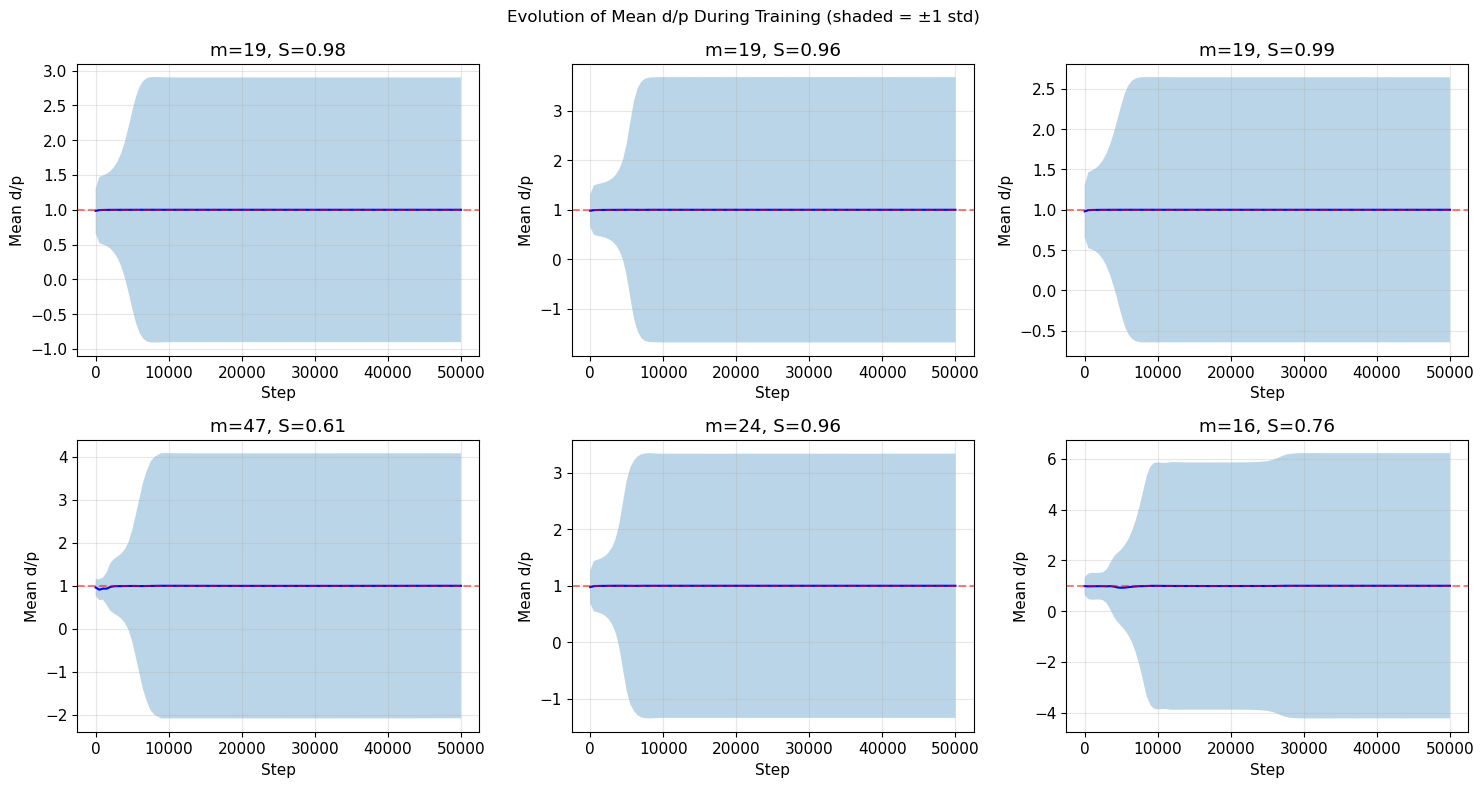

In [15]:
# Track how d/p evolves during training
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Select diverse experiments
def select_diverse_experiments(all_data, metadata, n=6):
    """Select experiments with diverse (m, sparsity) combinations."""
    # Get unique combinations
    seen = set()
    selected = []
    indices = list(range(len(all_data)))
    np.random.shuffle(indices)
    
    for idx in indices:
        key = (metadata[idx]['m'], round(metadata[idx]['sparsity'], 2))
        if key not in seen:
            seen.add(key)
            selected.append(idx)
            if len(selected) >= n:
                break
    return selected

selected_idxs = select_diverse_experiments(all_data, metadata, n=6)

for plot_idx, data_idx in enumerate(selected_idxs):
    ax = axes.flatten()[plot_idx]
    data = all_data[data_idx]
    meta = metadata[data_idx]
    
    # Compute mean d/p at each checkpoint
    p = meta['p']
    mean_d_over_p = np.mean(data['fractional_dims'] / p, axis=1)
    std_d_over_p = np.std(data['fractional_dims'] / p, axis=1)
    
    ax.fill_between(data['checkpoint_steps'], 
                    mean_d_over_p - std_d_over_p, 
                    mean_d_over_p + std_d_over_p,
                    alpha=0.3)
    ax.plot(data['checkpoint_steps'], mean_d_over_p, 'b-', linewidth=1.5)
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel('Step')
    ax.set_ylabel('Mean d/p')
    ax.set_title(f'm={meta["m"]}, S={meta["sparsity"]:.2f}')

plt.suptitle('Evolution of Mean d/p During Training (shaded = ±1 std)', fontsize=12)
plt.tight_layout()
plt.show()

## 12. Summary Report

In [16]:
print("=" * 70)
print("SWEEP DIAGNOSTICS SUMMARY")
print("=" * 70)
print()
print("COMPLETION STATUS:")
print(f"  Files found: {len(h5_files)} / {expected_total} ({100*len(h5_files)/expected_total:.1f}%)")
print(f"  Valid files: {len(all_data)}")
print(f"  Corrupted files: {len(corrupted_files)}")
print(f"  (m, sparsity) combinations complete (all 3 seeds): {fully_complete}")
print(f"  (m, sparsity) combinations partial: {partially_complete}")
print(f"  (m, sparsity) combinations missing: {missing}")
print()
print("FRACTIONAL DIMENSIONALITY (d/p):")
print(f"  Mean: {np.mean(all_d_flat):.4f}")
print(f"  Median: {np.median(all_d_flat):.4f}")
print(f"  Std: {np.std(all_d_flat):.4f}")
print(f"  Range: [{np.min(all_d_flat):.4f}, {np.max(all_d_flat):.4f}]")
print(f"  Features with d/p > 1: {(all_d_flat > 1).sum()} ({100*(all_d_flat > 1).sum()/len(all_d_flat):.2f}%)")
print()
print("LOSS CONVERGENCE:")
print(f"  Mean final loss: {np.mean(final_losses):.6f}")
print(f"  Median final loss: {np.median(final_losses):.6f}")
print(f"  High loss experiments (>95%ile): {len(high_loss_experiments)}")
print()
print("FEATURE HEALTH:")
print(f"  Dead features (norm < 1e-6): {dead_features} ({100*dead_features/len(all_final_norms):.2f}%)")
print()
print("POTENTIAL ISSUES:")
issues = []
if len(corrupted_files) > 0:
    issues.append(f"- {len(corrupted_files)} corrupted h5 files detected")
if dead_features / len(all_final_norms) > 0.1:
    issues.append(f"- High proportion of dead features ({100*dead_features/len(all_final_norms):.1f}%)")
if len(high_loss_experiments) > len(all_data) * 0.1:
    issues.append(f"- Many experiments with high final loss")
if len(h5_files) < expected_total * 0.5:
    issues.append(f"- Less than 50% of experiments completed")

if issues:
    for issue in issues:
        print(f"  {issue}")
else:
    print("  No major issues detected in completed experiments")
    
print("\n" + "=" * 70)

SWEEP DIAGNOSTICS SUMMARY

COMPLETION STATUS:
  Files found: 550 / 1800 (30.6%)
  Valid files: 550
  Corrupted files: 0
  (m, sparsity) combinations complete (all 3 seeds): 180
  (m, sparsity) combinations partial: 6
  (m, sparsity) combinations missing: 414

FRACTIONAL DIMENSIONALITY (d/p):


NameError: name 'all_d_flat' is not defined

In [17]:
# List missing (m, sparsity) combinations
missing_combos = []
for m in m_unique:
    for s in s_unique:
        key = (int(m), round(s, 6))
        if key not in completion_map or len(completion_map[key]) == 0:
            missing_combos.append((m, s))

if missing_combos:
    print(f"\nMissing combinations (first 20 of {len(missing_combos)}):")
    for m, s in missing_combos[:20]:
        print(f"  m={m}, sparsity={s:.6f}")


Missing combinations (first 20 of 414):
  m=59, sparsity=0.614338
  m=59, sparsity=0.670966
  m=59, sparsity=0.719278
  m=59, sparsity=0.760497
  m=59, sparsity=0.795664
  m=59, sparsity=0.825667
  m=59, sparsity=0.851265
  m=59, sparsity=0.873104
  m=59, sparsity=0.891736
  m=59, sparsity=0.907633
  m=59, sparsity=0.921195
  m=59, sparsity=0.932766
  m=59, sparsity=0.942638
  m=59, sparsity=0.951061
  m=59, sparsity=0.958247
  m=59, sparsity=0.964378
  m=59, sparsity=0.969608
  m=59, sparsity=0.974071
  m=59, sparsity=0.977878
  m=59, sparsity=0.981126
